# Part A - Data Loading and Preprocessing with Scikit-learn

## Task-1

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("hotel_bookings.csv")

In [ ]:
# First 5 rows
df.head(5)

# Number of rows and columns
df.shape

# Information about columns, data types, and missing values
df.info()

# Statistical summary of numerical columns
df.describe()

# Data types of all columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
# Class distribution
df["is_canceled"].value_counts()

df["is_canceled"].value_counts(normalize=True) * 100

y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])
print("X shape:", X.shape)
print("y shape:", y.shape)

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)
print("\nCategorical columns:")
print(categorical_cols)

X shape: (119390, 31)
y shape: (119390,)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


## Task-2

In [ ]:
# Missing value count
missing_count = df.isnull().sum()

# Missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show all columns
missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False )

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


In [ ]:
high_missing = missing_summary[missing_summary["Missing Percentage"] > 50]
print(high_missing)
df = df.drop(columns=["company"])

# The company column was dropped because it contains a very high
# proportion of missing values. Since most bookings do not have a
# company associated with them, retaining this feature would provide
# limited useful information and introduce substantial missing-value
# handling.

         Missing Count  Missing Percentage
company         112593           94.306893


['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


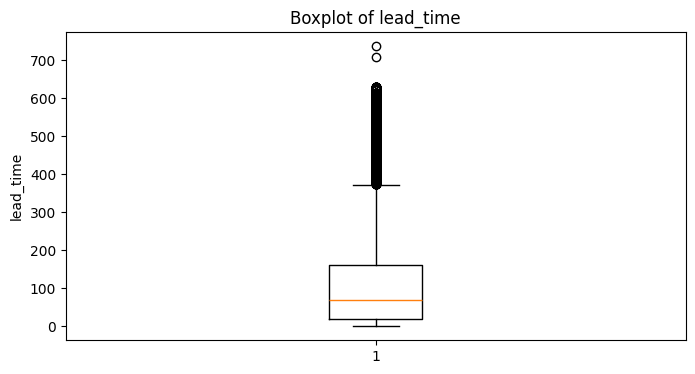

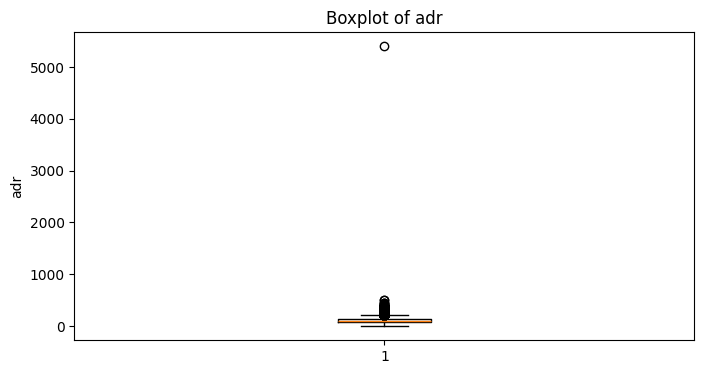

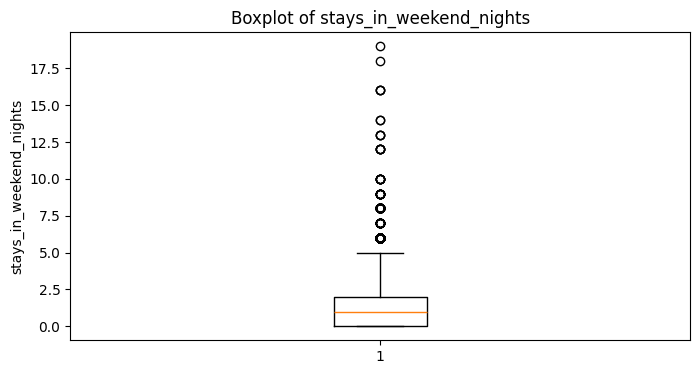

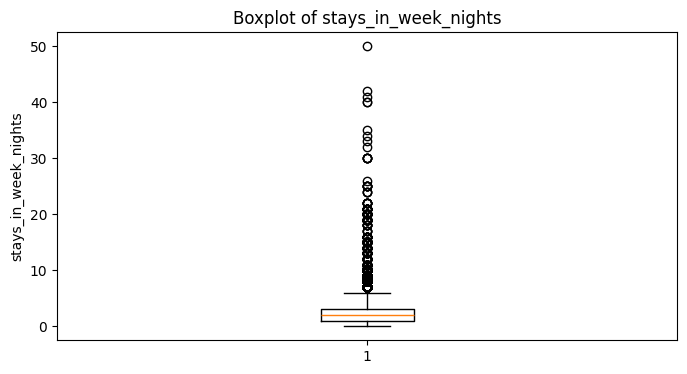

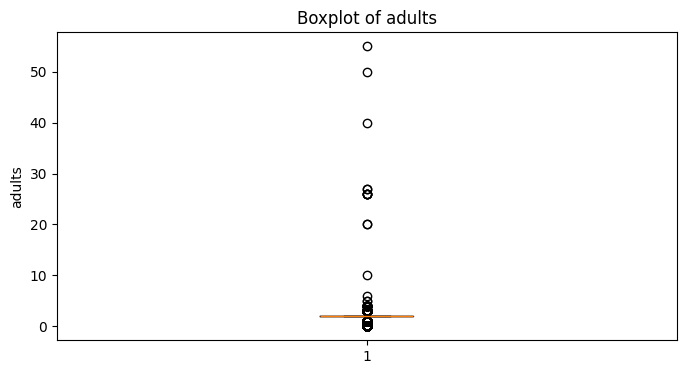

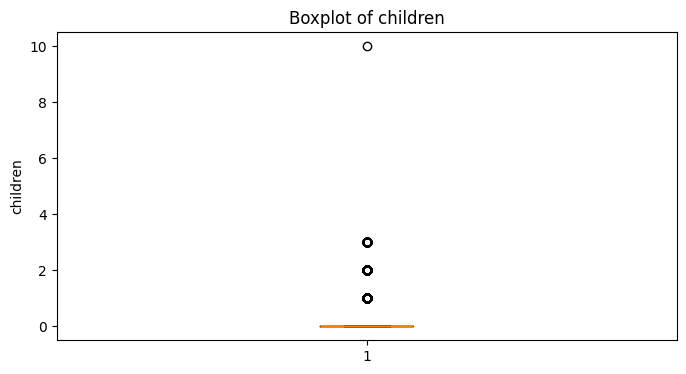

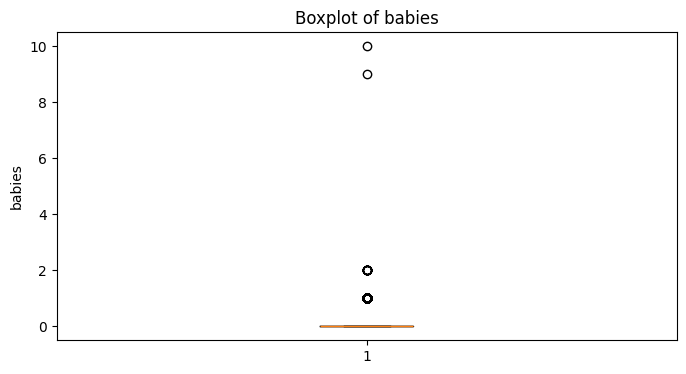

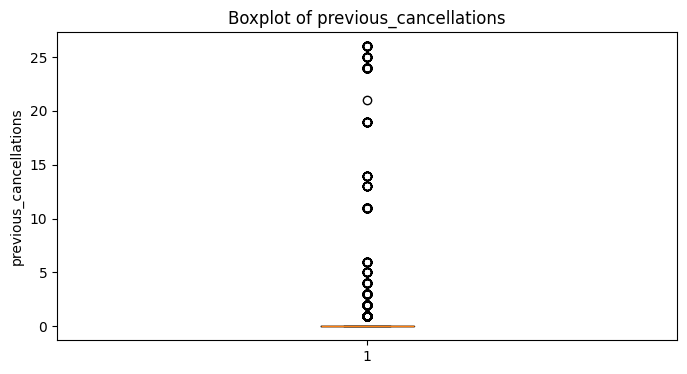

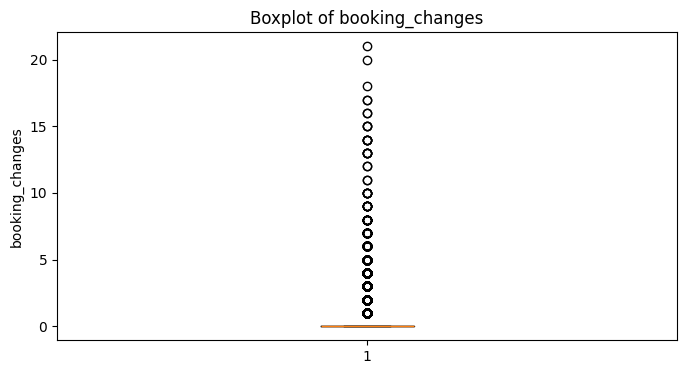

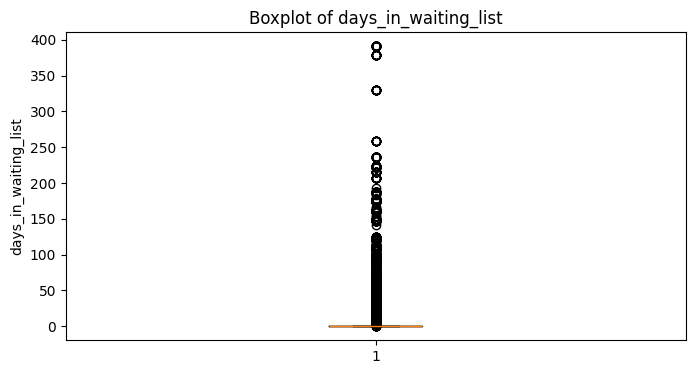

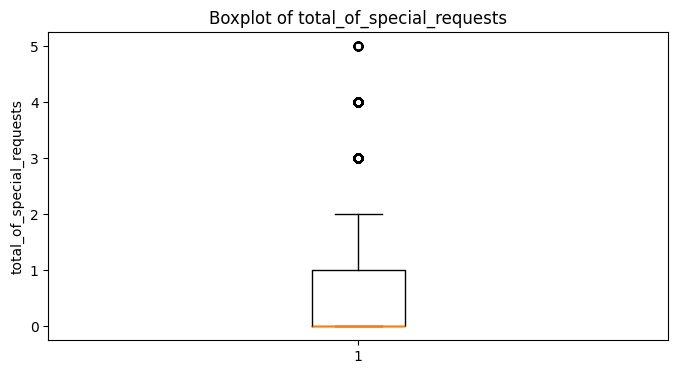

Rows before: 119390
Rows after: 119372
Rows removed: 18


In [ ]:
df = df.drop(
    columns=["reservation_status", "reservation_status_date"] )

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numerical_cols)

# box plot
selected_numeric = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests" ]

import matplotlib.pyplot as plt
for col in selected_numeric:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

# IQR method
outlier_summary = []
for col in selected_numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound) ]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers) })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

# removing outliers
rows_before = len(df)
df = df[
    (df["adults"] <= 10) &
    (df["children"] <= 10) &
    (df["babies"] <= 5) ]

rows_after = len(df)
rows_removed = rows_before - rows_after
print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_removed)

## Task-3

In [ ]:
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

numerical_cols = X.select_dtypes(
    include=["int64", "float64"] ).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"] ).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)
print("\nCategorical columns:")
print(categorical_cols)

X shape: (119372, 28)
y shape: (119372,)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [ ]:
# split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42 )

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (95497, 28)
Testing data: (23875, 28)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, OneHotEncoder)

In [ ]:
# For categorical columns
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])  # same for both the pipelines

# pipeline A
numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

pipeline_A = Pipeline([ ("preprocessor", preprocessor_A) ])

# pipeline B
numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

pipeline_B = Pipeline([ ("preprocessor", preprocessor_B) ])

In [ ]:
pipeline_A.fit(X_train, y_train)
pipeline_B.fit(X_train, y_train)

X_train_A = pipeline_A.transform(X_train)
X_test_A = pipeline_A.transform(X_test)

X_train_B = pipeline_B.transform(X_train)
X_test_B = pipeline_B.transform(X_test)

In [ ]:
df.to_csv("preprocessed_data.csv", index=False)

# Part B - Model Training and Performance Evaluation

## Task-4

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Logistic Regression + Pipeline A
logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Logistic Regression + Pipeline B
logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Decision Tree + Pipeline A
tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Decision Tree + Pipeline B
tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [ ]:
# Training Logistic Regression + Pipeline A
logistic_A.fit(X_train, y_train)

# Training Logistic Regression + Pipeline B
logistic_B.fit(X_train, y_train)

# Training Decision Tree + Pipeline A
tree_A.fit(X_train, y_train)

# Training Decision Tree + Pipeline B
tree_B.fit(X_train, y_train)

print("Trained successfully!")

Trained successfully!


## Task-5

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
models = {
    "Logistic Regression + Pipeline A": logistic_A,
    "Logistic Regression + Pipeline B": logistic_B,
    "Decision Tree + Pipeline A": tree_A,
    "Decision Tree + Pipeline B": tree_B
}

results = []
for name, model in models.items():
    y_train_pred = model.predict(X_train)  # Predictions on training data
    y_test_pred = model.predict(X_test)  # Predictions on testing data

    # Metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    results.append({
        "Model-Pipeline": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)


Best Logistic Regression: 
 Model-Pipeline           Logistic Regression + Pipeline A
Training Accuracy                                0.819219
Testing Accuracy                                 0.816545
Precision                                        0.805868
Recall                                           0.664782
F1-Score                                         0.728557
Train-Test Difference                            0.002675
Name: 0, dtype: object

Best Decision Tree: 
 Model-Pipeline           Decision Tree + Pipeline B
Training Accuracy                          0.996084
Testing Accuracy                           0.859686
Precision                                  0.808055
Recall                                     0.814635
F1-Score                                   0.811331
Train-Test Difference                      0.136398
Name: 3, dtype: object


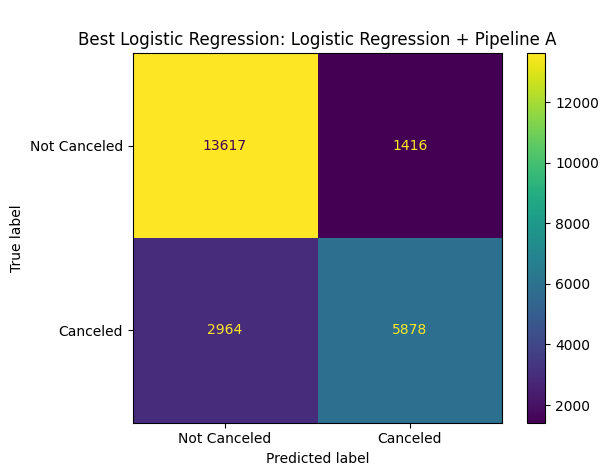

<Figure size 640x480 with 0 Axes>

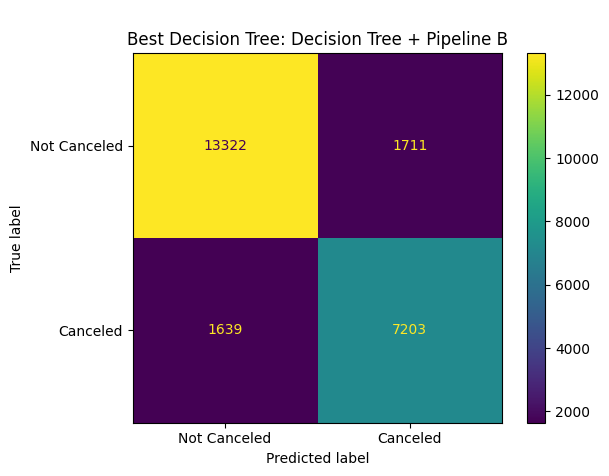

<Figure size 640x480 with 0 Axes>

In [ ]:
results_df["Train-Test Difference"] = (results_df["Training Accuracy"] - results_df["Testing Accuracy"] )
results_df.round(4)

# best Logistic Regression result
logistic_results = results_df[
    results_df["Model-Pipeline"].str.startswith("Logistic Regression")
]

best_logistic = logistic_results.loc[
    logistic_results["F1-Score"].idxmax()
]

print("\nBest Logistic Regression: \n", best_logistic)

# best Decision Tree result
tree_results = results_df[
    results_df["Model-Pipeline"].str.startswith("Decision Tree")
]

best_tree = tree_results.loc[
    tree_results["F1-Score"].idxmax()
]

print("\nBest Decision Tree: \n", best_tree)

# confusion matrix for best Logistic Regression result
best_logistic_name = best_logistic["Model-Pipeline"]

best_logistic_model = models[best_logistic_name]

y_pred_logistic = best_logistic_model.predict(X_test)

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title(f"\nBest Logistic Regression: {best_logistic_name}")
plt.show()
plt.savefig("confusion_matrix_logistic_regression.jpg")

# confusion matrix for best Decision Tree result
best_tree_name = best_tree["Model-Pipeline"]
best_tree_model = models[best_tree_name]
y_pred_tree = best_tree_model.predict(X_test)

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title(f"\nBest Decision Tree: {best_tree_name}")
plt.show()
plt.savefig("confusion_matrix_decision_tree.jpg")

In [ ]:
# overfitting check
for _, row in results_df.iterrows():
    print(
        row["Model-Pipeline"],
        "→ Train-Test Difference:",
        round(row["Train-Test Difference"], 4)
    )

results_df.to_csv("model_performance.csv", index=False)

Logistic Regression + Pipeline A → Train-Test Difference: 0.0027
Logistic Regression + Pipeline B → Train-Test Difference: 0.003
Decision Tree + Pipeline A → Train-Test Difference: 0.1365
Decision Tree + Pipeline B → Train-Test Difference: 0.1364
